In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


Проверяем формат столбцов

In [5]:
df['Дата'] = pd.to_datetime(df['Дата'])

Сразу переведем столбец "Дата" в правильный формат

In [8]:
grouped_df = df.groupby('Дата')['Количество'].sum()

Сгруппируйте данные по дате, посчитайте количество продаж

In [10]:
grouped_df 

Дата
2018-01-04    3734
2018-01-05    3643
2018-01-06    3193
2018-01-07    3298
2018-01-09    4055
              ... 
2018-08-26    5302
2018-08-28    5983
2018-08-29    4969
2018-08-30    4648
2018-08-31    4570
Name: Количество, Length: 205, dtype: int64

Вывести несколько первых строк сгруппированных данных

In [11]:
print(grouped_df.head())

Дата
2018-01-04    3734
2018-01-05    3643
2018-01-06    3193
2018-01-07    3298
2018-01-09    4055
Name: Количество, dtype: int64


Нарисуйте график продаж у `grouped_df`

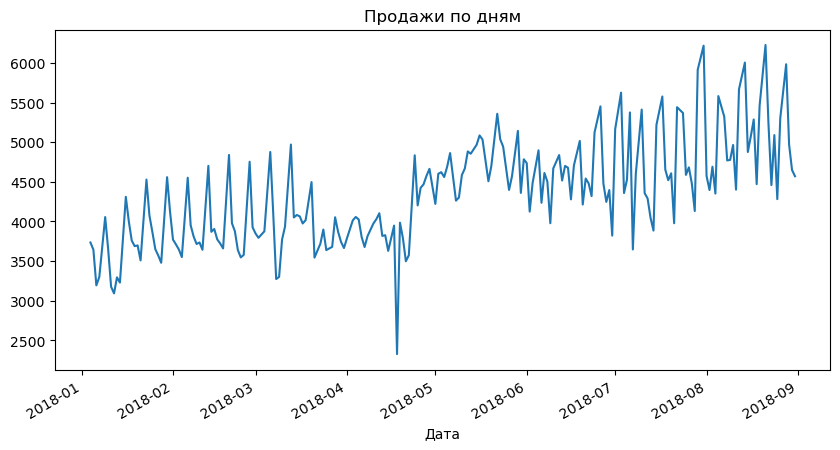

In [12]:
grouped_df.plot(kind='line', figsize=(10, 5), title='Продажи по дням')
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [ ]:
На графике наблюдается устойчивый положительный тренд роста продаж с января по сентябрь. Есть выраженная недельная сезонность.
В мае зафиксировано аномальное падение продаж (выброс вниз), а пик активности приходится на август, где волатильность данных максимальна».

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [14]:
max_outlier = df[df['Количество'] == df['Количество'].max()]
print(max_outlier)

             Дата  Склад   Контрагент Номенклатура  Количество
218822 2018-06-28      1  address_208    product_0         200


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [15]:
summer_df = df[(df['Склад'] == 3) & (df['Дата'].dt.month.isin([6, 7, 8]))]
wednesdays_df = summer_df[summer_df['Дата'].dt.dayofweek == 2]
top_product = wednesdays_df.groupby('Номенклатура')['Количество'].sum().idxmax()

print(f"Самый популярный товар: {top_product}")

Самый популярный товар: product_1


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
weather = pd.read_excel('astana2018w.xlsx')
weather_clean = weather.iloc[:, [0, 1]].copy()
weather_clean.columns = ['Дата_время', 'T']

weather_clean['Дата_время'] = pd.to_datetime(weather_clean['Дата_время'], errors='coerce')
weather_clean['T'] = pd.to_numeric(weather_clean['T'], errors='coerce')
weather_clean = weather_clean.dropna(subset=['Дата_время', 'T'])

weather_clean['Дата'] = weather_clean['Дата_время'].dt.normalize()
daily_temp = weather_clean.groupby('Дата')['T'].mean().reset_index()

sales_df = grouped_df.reset_index() if isinstance(grouped_df, pd.Series) else grouped_df.copy()
sales_df.columns = ['Дата', 'Продажи']
sales_df['Дата'] = pd.to_datetime(sales_df['Дата']).dt.normalize()

final_df = pd.merge(sales_df, daily_temp, on='Дата', how='inner')


Строк в погоде: 274
Общих строк: 143


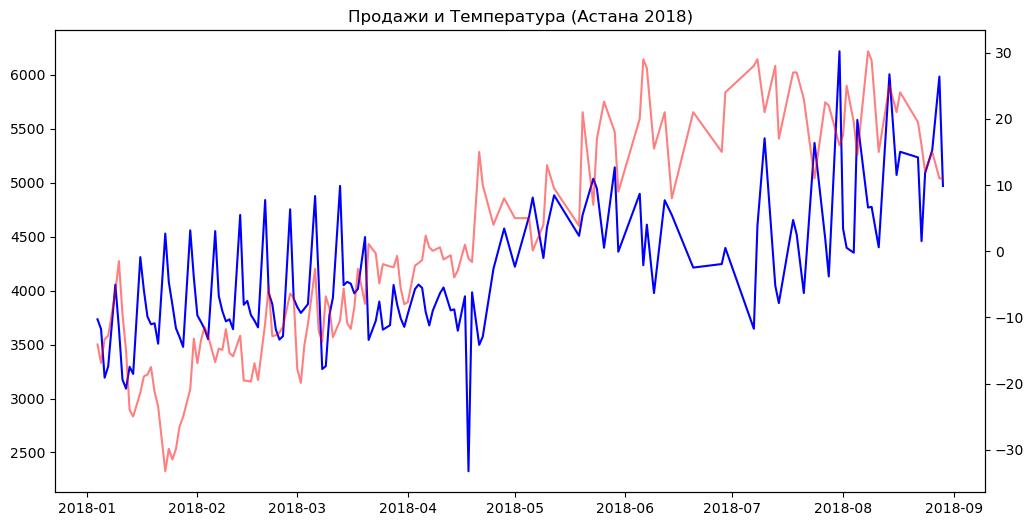

In [56]:
print(f"Строк в погоде: {len(daily_temp)}")
print(f"Общих строк: {len(final_df)}")

if len(final_df) > 0:
    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax1.plot(final_df['Дата'], final_df['Продажи'], color='blue', label='Продажи')
    ax2 = ax1.twinx()
    ax2.plot(final_df['Дата'], final_df['T'], color='red', alpha=0.5, label='Температура')
    plt.title('Продажи и Температура (Астана 2018)')
    plt.show()
else:
    print("Данные не пересеклись. Проверь даты:")
    print("Погода:", daily_temp['Дата'].head(2).tolist())
    print("Продажи:", sales_df['Дата'].head(2).tolist())